# Early Hospital Readmission Risk Analysis & Prediction

## 1. Project Overview

### Problem Statement

Can we identify patient and hospital-encounter characteristics associated with
early readmission among patients with diabetes, and build a machine-learning
model to predict whether a patient will be readmitted within 30 days?

### Objective

The project focuses on exploratory data analysis, feature engineering, and
machine-learning-based prediction of early hospital readmission.

### Dataset

**UCI Diabetes 130-US Hospitals for Years 1999–2008**

The dataset contains hospital encounters for patients with diabetes across
130 U.S. hospitals and integrated delivery networks during 1999–2008.

### Target

The original `readmitted` variable contains three categories:

- `<30` — readmitted within 30 days
- `>30` — readmitted after 30 days
- `NO` — not readmitted

For this project, the problem is formulated as binary classification:

- `<30` → `1` (early readmission)
- `>30` → `0`
- `NO` → `0`

### Important Considerations

- The dataset is historical (1999–2008).
- The analysis describes associations and predictive relationships, not causation.
- Multiple encounters can belong to the same patient, so patient-level data leakage
  must be prevented during train-test splitting.

## 2. Data Loading and Initial Inspection

We first load the raw dataset and inspect its dimensions, structure, and target
distribution before performing any preprocessing.

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [132]:
df = pd.read_csv("/content/diabetic_data.csv")

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [133]:
print("Shape:", df.shape)
print("Number of unique patients:", df["patient_nbr"].nunique())

df.info()

Shape: (101766, 50)
Number of unique patients: 71518
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_pr

In [134]:
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [135]:
df["readmitted"].value_counts(normalize=True) * 100

,proportion
readmitted,
NO,53.911916
>30,34.928169
<30,11.159916


## 3. Data Quality Audit

Before preprocessing the dataset, we inspect missing-value patterns, duplicate
records, variable types, categorical distributions, and numerical summaries.

The dataset uses `?` to represent missing values, so these values must be
converted to proper missing-value representations before calculating missingness.

In [136]:
missing_question_marks = (df == "?").sum()

missing_question_marks[missing_question_marks > 0].sort_values(ascending=False)

,0
weight,98569
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


In [137]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [138]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [139]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- race ---
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

--- weight ---
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

--- payer_code ---
payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
Name: co

In [140]:
# Convert '?' to proper missing values
df = df.replace("?", np.nan)

# Check missing values again
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


In [141]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
)

missing_summary

,missing_count,missing_percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [142]:
cols_to_drop_missing = [
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

df = df.drop(columns=cols_to_drop_missing)

print("New shape:", df.shape)

New shape: (101766, 45)


In [143]:
cols_to_impute = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

df[cols_to_impute] = df[cols_to_impute].fillna("Unknown")

In [144]:
df["gender"] = df["gender"].replace("Unknown/Invalid", "Unknown")

In [145]:
remaining_missing = df.isnull().sum()

remaining_missing[remaining_missing > 0]

,0


## 4. Target Engineering

The original `readmitted` variable has three categories. Since our objective is
specifically to identify readmissions occurring within 30 days, we convert this
into a binary classification target called `early_readmission`.

- `<30` → `1` (early readmission)
- `>30` → `0`
- `NO` → `0`

In [146]:
df["early_readmission"] = (df["readmitted"] == "<30").astype(int)

df["early_readmission"].value_counts()

,count
early_readmission,
0,90409
1,11357


In [147]:
df["early_readmission"].value_counts(normalize=True) * 100

,proportion
early_readmission,
0,88.840084
1,11.159916


In [148]:
pd.crosstab(df["readmitted"], df["early_readmission"])

early_readmission,0,1
readmitted,,
<30,0,11357
>30,35545,0
NO,54864,0


In [149]:
print("Unique encounters:", df["encounter_id"].nunique())
print("Unique patients:", df["patient_nbr"].nunique())
print("Total rows:", len(df))

Unique encounters: 101766
Unique patients: 71518
Total rows: 101766


In [150]:
patient_counts = df["patient_nbr"].value_counts()

print("Patients with multiple encounters:",
      (patient_counts > 1).sum())

print("Maximum encounters for one patient:",
      patient_counts.max())

Patients with multiple encounters: 16773
Maximum encounters for one patient: 40


In [151]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted',
 'early_readmission']

In [152]:
print(
    df.groupby("patient_nbr")["early_readmission"]
      .agg(["count", "sum"])
      .sort_values("count", ascending=False)
      .head(10)
)

             count  sum
patient_nbr            
88785891        40   23
43140906        28   22
1660293         23   11
23199021        23    7
88227540        23   12
84428613        22   12
23643405        22   12
92709351        21   12
89472402        20   11
88789707        20    7


In [153]:
patient_target_counts = (
    df.groupby("patient_nbr")["early_readmission"]
      .nunique()
)

print("Patients with both 0 and 1 outcomes:",
      (patient_target_counts > 1).sum())

print("Patients with only one outcome:",
      (patient_target_counts == 1).sum())

Patients with both 0 and 1 outcomes: 6481
Patients with only one outcome: 65037


## 5. Patient-Level Train/Test Split

The dataset contains multiple hospital encounters for some patients. A random
row-level split could place encounters from the same patient into both the
training and testing datasets, resulting in patient-level information leakage.

Therefore, we split the unique patients first and then assign all encounters
belonging to each patient to the corresponding partition.

We use an 80/20 patient-level train/test split with a fixed random state for
reproducibility.

In [154]:
from sklearn.model_selection import train_test_split

# Get unique patient IDs
unique_patients = df["patient_nbr"].unique()

# Split patients, not individual encounters
train_patients, test_patients = train_test_split(
    unique_patients,
    test_size=0.20,
    random_state=42
)

print("Training patients:", len(train_patients))
print("Testing patients:", len(test_patients))

Training patients: 57214
Testing patients: 14304


In [155]:
train_df = df[df["patient_nbr"].isin(train_patients)].copy()
test_df = df[df["patient_nbr"].isin(test_patients)].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (81477, 46)
Test shape: (20289, 46)


In [156]:
train_patient_set = set(train_df["patient_nbr"])
test_patient_set = set(test_df["patient_nbr"])

overlap = train_patient_set.intersection(test_patient_set)

print("Patients appearing in both train and test:", len(overlap))

Patients appearing in both train and test: 0


In [157]:
print("Training target distribution:")
print(train_df["early_readmission"].value_counts())
print(train_df["early_readmission"].value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(test_df["early_readmission"].value_counts())
print(test_df["early_readmission"].value_counts(normalize=True) * 100)

Training target distribution:
early_readmission
0    72289
1     9188
Name: count, dtype: int64
early_readmission
0    88.723198
1    11.276802
Name: proportion, dtype: float64

Testing target distribution:
early_readmission
0    18120
1     2169
Name: count, dtype: int64
early_readmission
0    89.309478
1    10.690522
Name: proportion, dtype: float64


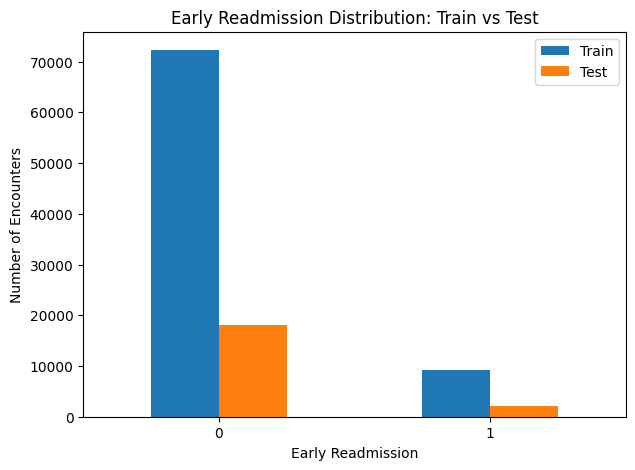

In [158]:
target_counts = pd.DataFrame({
    "Train": train_df["early_readmission"].value_counts(),
    "Test": test_df["early_readmission"].value_counts()
})

target_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Early Readmission Distribution: Train vs Test")
plt.xlabel("Early Readmission")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=0)
plt.legend()
plt.show()

### Train/Test Target Distribution

The positive class represents approximately 11% of encounters in both the
training and testing sets. The proportions are reasonably similar, indicating
that the patient-level split produced comparable target distributions.

No patient appears in both datasets, preventing direct patient-level leakage
between training and testing data.

## 6. Feature Engineering

The raw dataset contains several coded categorical variables, including admission
type, discharge disposition, and admission source. These identifiers are mapped
to their corresponding descriptive categories using the provided
`IDS_mapping.csv` file.

We will also transform other variables into representations that are more
appropriate for exploratory analysis and machine learning.

In [159]:
ids_map = pd.read_csv("/content/IDS_mapping.csv")

ids_map.head()

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


In [160]:
print("Shape:", ids_map.shape)
print("\nColumns:")
print(ids_map.columns.tolist())

print("\nMapping data:")
print(ids_map)

Shape: (67, 2)

Columns:
['admission_type_id', 'description']

Mapping data:
           admission_type_id  \
0                          1   
1                          2   
2                          3   
3                          4   
4                          5   
5                          6   
6                          7   
7                          8   
8                        NaN   
9   discharge_disposition_id   
10                         1   
11                         2   
12                         3   
13                         4   
14                         5   
15                         6   
16                         7   
17                         8   
18                         9   
19                        10   
20                        11   
21                        12   
22                        13   
23                        14   
24                        15   
25                        16   
26                        17   
27                        1

### 6.1 Mapping Coded Hospital Variables

The dataset contains coded variables for admission type, discharge disposition,
and admission source. The accompanying `IDS_mapping.csv` file provides the
descriptions corresponding to these codes.

We convert these coded identifiers into descriptive categorical variables so
that the resulting features are more interpretable during exploratory analysis
and modeling.

In [161]:
# Identify the rows that mark the beginning of each mapping section
ids_map[ids_map["admission_type_id"].isna()]

,admission_type_id,description
8,NaN,NaN
40,NaN,NaN


In [162]:
# Find the rows marking the beginning of the
# discharge disposition and admission source sections

discharge_start = ids_map.index[
    ids_map["admission_type_id"] == "discharge_disposition_id"
][0]

source_start = ids_map.index[
    ids_map["admission_type_id"] == "admission_source_id"
][0]

print("Discharge section starts at:", discharge_start)
print("Source section starts at:", source_start)

Discharge section starts at: 9
Source section starts at: 41


In [163]:
# Admission type mapping
admission_map = ids_map.loc[
    0:7,
    ["admission_type_id", "description"]
].copy()

# Discharge disposition mapping
discharge_map = ids_map.loc[
    discharge_start + 1 : source_start - 2,
    ["admission_type_id", "description"]
].copy()

# Admission source mapping
source_map = ids_map.loc[
    source_start + 1 :,
    ["admission_type_id", "description"]
].copy()

# Rename columns to their actual meaning
discharge_map.columns = [
    "discharge_disposition_id",
    "discharge_disposition"
]

source_map.columns = [
    "admission_source_id",
    "admission_source"
]

print("Admission mappings:", len(admission_map))
print("Discharge mappings:", len(discharge_map))
print("Source mappings:", len(source_map))

Admission mappings: 8
Discharge mappings: 30
Source mappings: 25


In [164]:
# Remove rows without a valid mapping
admission_map = admission_map.dropna(subset=["admission_type_id"])
discharge_map = discharge_map.dropna(subset=["discharge_disposition_id"])
source_map = source_map.dropna(subset=["admission_source_id"])

# Rename columns to their actual meanings
admission_map.columns = [
    "admission_type_id",
    "admission_type"
]

discharge_map.columns = [
    "discharge_disposition_id",
    "discharge_disposition"
]

source_map.columns = [
    "admission_source_id",
    "admission_source"
]

# Convert IDs to integers
admission_map["admission_type_id"] = admission_map["admission_type_id"].astype(int)
discharge_map["discharge_disposition_id"] = discharge_map["discharge_disposition_id"].astype(int)
source_map["admission_source_id"] = source_map["admission_source_id"].astype(int)

print(admission_map)
print(discharge_map.head())
print(source_map.head())

   admission_type_id admission_type
0                  1      Emergency
1                  2         Urgent
2                  3       Elective
3                  4        Newborn
4                  5  Not Available
5                  6            NaN
6                  7  Trauma Center
7                  8     Not Mapped
    discharge_disposition_id  \
10                         1   
11                         2   
12                         3   
13                         4   
14                         5   

                                discharge_disposition  
10                                 Discharged to home  
11  Discharged/transferred to another short term h...  
12                      Discharged/transferred to SNF  
13                      Discharged/transferred to ICF  
14  Discharged/transferred to another type of inpa...  
    admission_source_id                                 admission_source
42                    1                               Physician Referral
4

In [165]:
admission_dict = dict(
    zip(admission_map["admission_type_id"],
        admission_map["admission_type"])
)

discharge_dict = dict(
    zip(discharge_map["discharge_disposition_id"],
        discharge_map["discharge_disposition"])
)

source_dict = dict(
    zip(source_map["admission_source_id"],
        source_map["admission_source"])
)

print(admission_dict)
print("\n", discharge_dict)
print("\n", source_dict)

{1: 'Emergency', 2: 'Urgent', 3: 'Elective', 4: 'Newborn', 5: 'Not Available', 6: nan, 7: 'Trauma Center', 8: 'Not Mapped'}

 {1: 'Discharged to home', 2: 'Discharged/transferred to another short term hospital', 3: 'Discharged/transferred to SNF', 4: 'Discharged/transferred to ICF', 5: 'Discharged/transferred to another type of inpatient care institution', 6: 'Discharged/transferred to home with home health service', 7: 'Left AMA', 8: 'Discharged/transferred to home under care of Home IV provider', 9: 'Admitted as an inpatient to this hospital', 10: 'Neonate discharged to another hospital for neonatal aftercare', 11: 'Expired', 12: 'Still patient or expected to return for outpatient services', 13: 'Hospice / home', 14: 'Hospice / medical facility', 15: 'Discharged/transferred within this institution to Medicare approved swing bed', 16: 'Discharged/transferred/referred another institution for outpatient services', 17: 'Discharged/transferred/referred to this institution for outpatient s

### 6.2 Applying the Mappings

The validated mapping dictionaries are applied to the corresponding coded
variables in the training and testing datasets.

The original numeric ID columns are retained temporarily so that we can verify
the mapping. Descriptions that are unavailable in the mapping file are
represented as `Unknown`.

In [166]:
# Apply mappings to both training and testing datasets
for data in [train_df, test_df]:
    data["admission_type"] = data["admission_type_id"].map(admission_dict)
    data["discharge_disposition"] = data["discharge_disposition_id"].map(discharge_dict)
    data["admission_source"] = data["admission_source_id"].map(source_dict)

    # Clean whitespace and handle unavailable descriptions
    for col in ["admission_type", "discharge_disposition", "admission_source"]:
        data[col] = data[col].astype("string").str.strip().fillna("Unknown")

In [167]:
print("Admission types:")
print(train_df["admission_type"].value_counts())

print("\nDischarge dispositions:")
print(train_df["discharge_disposition"].value_counts().head(15))

print("\nAdmission sources:")
print(train_df["admission_source"].value_counts().head(15))

Admission types:
admission_type
Emergency        43304
Elective         15074
Urgent           14725
Unknown           4207
Not Available     3887
Not Mapped         255
Trauma Center       17
Newborn              8
Name: count, dtype: Int64

Discharge dispositions:
discharge_disposition
Discharged to home                                                                                           48161
Discharged/transferred to SNF                                                                                11176
Discharged/transferred to home with home health service                                                      10394
Unknown                                                                                                       2977
Discharged/transferred to another short term hospital                                                         1703
Discharged/transferred to another rehab fac including rehab units of a hospital .                             1594
Expired              

In [168]:
print("Unmapped admission type IDs:",
      sorted(set(train_df["admission_type_id"]) - set(admission_dict)))

print("Unmapped discharge disposition IDs:",
      sorted(set(train_df["discharge_disposition_id"]) - set(discharge_dict)))

print("Unmapped admission source IDs:",
      sorted(set(train_df["admission_source_id"]) - set(source_dict)))

Unmapped admission type IDs: []
Unmapped discharge disposition IDs: []
Unmapped admission source IDs: []


### 6.3 Removing Redundant Identifier Features

After validating the mappings, the original numeric identifier columns are
removed because their descriptive categorical counterparts now contain the
same information in a more interpretable form.

The patient and encounter identifiers are retained temporarily because they are
needed for data management and leakage checks, but they will not be used as
predictive features.

In [169]:
# Remove the original coded categorical IDs
id_cols_to_remove = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

train_df = train_df.drop(columns=id_cols_to_remove)
test_df = test_df.drop(columns=id_cols_to_remove)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (81477, 46)
Test shape: (20289, 46)


In [170]:
print(train_df.columns.tolist())

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'early_readmission', 'admission_type', 'discharge_disposition', 'admission_source']


## 7. Exploratory Data Analysis

Exploratory data analysis is used to understand how patient characteristics,
hospital encounters, and treatment patterns relate to early readmission.

Rather than plotting every variable indiscriminately, we focus on variables for
which the relationship with the target is meaningful and interpretable.

### 7.1 Demographic Characteristics

We first examine demographic variables such as age, gender, and race to determine
whether the observed rate of early readmission differs across patient groups.

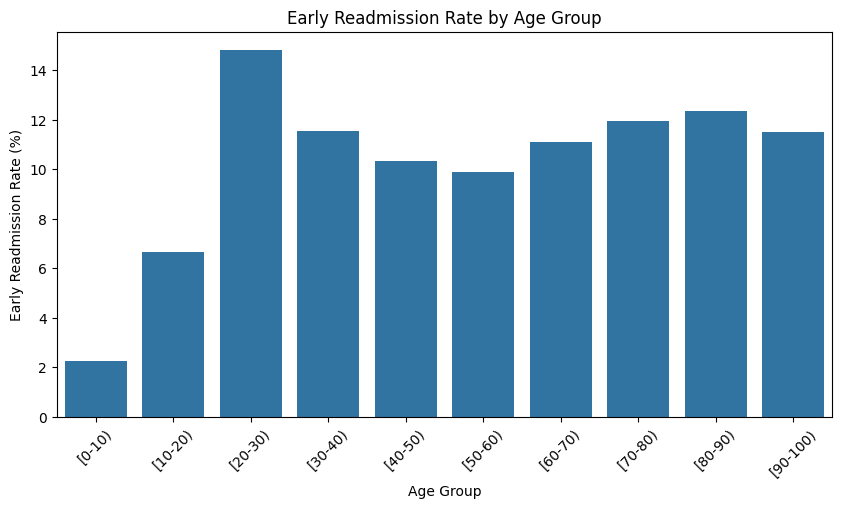

In [171]:
age_readmission = (
    train_df.groupby("age")["early_readmission"]
    .mean()
    .mul(100)
    .reindex(sorted(train_df["age"].unique()))
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=age_readmission.index,
    y=age_readmission.values
)

plt.title("Early Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Early Readmission Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [172]:
age_readmission.round(2)

,early_readmission
age,
[0-10),2.26
[10-20),6.67
[20-30),14.81
[30-40),11.55
[40-50),10.31
[50-60),9.88
[60-70),11.09
[70-80),11.93
[80-90),12.33


#### Age and Early Readmission

The observed early-readmission rate varies across age groups. The `[20-30)` age
group has the highest observed rate in the training data at 14.81%, while the
`[0-10)` group has the lowest at 2.26%.

However, the youngest age groups contain relatively few encounters, so their
estimated rates should be interpreted cautiously. The older age groups show
more moderate differences in early-readmission rates.

These results describe associations in the dataset and do not imply that age
itself causes early readmission.

### 7.2 Gender and Early Readmission

We next examine the distribution of encounters by gender and compare the
early-readmission rate between gender groups.

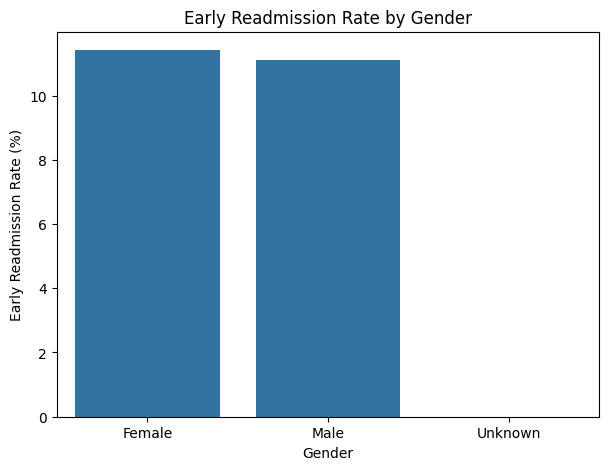

In [173]:
gender_readmission = (
    train_df.groupby("gender")["early_readmission"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_readmission.index,
    y=gender_readmission.values
)

plt.title("Early Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Early Readmission Rate (%)")

plt.show()

In [174]:
gender_readmission.round(2)

,early_readmission
gender,
Female,11.42
Male,11.12
Unknown,0.00


#### Gender and Early Readmission

The observed early-readmission rates are similar for female and male encounters,
at 11.42% and 11.12%, respectively. This suggests only a small difference in
early-readmission rates between these two groups in the training data.

The `Unknown` category contains only three encounters, so its observed rate is
not reliable enough to interpret.

### 7.3 Race and Early Readmission

We next examine the distribution of encounters across race categories and compare
the observed early-readmission rate between groups.

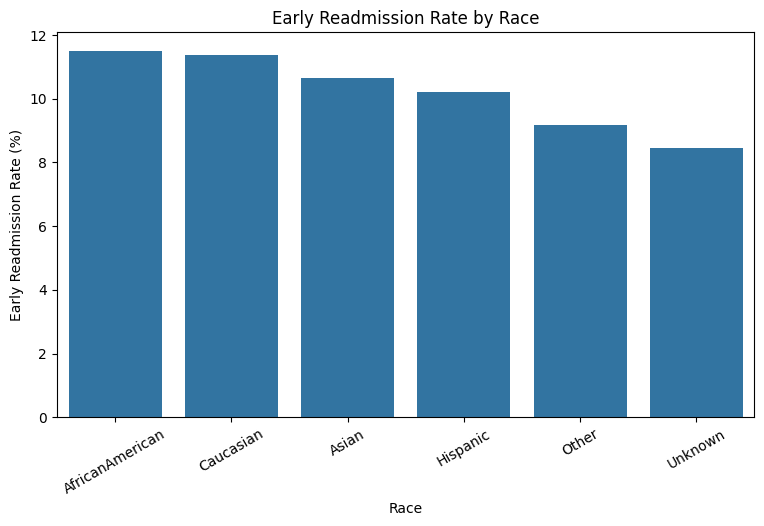

In [175]:
race_readmission = (
    train_df.groupby("race")["early_readmission"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=race_readmission.index,
    y=race_readmission.values
)

plt.title("Early Readmission Rate by Race")
plt.xlabel("Race")
plt.ylabel("Early Readmission Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [176]:
race_readmission.round(2)

,early_readmission
race,
AfricanAmerican,11.51
Caucasian,11.38
Asian,10.65
Hispanic,10.23
Other,9.17
Unknown,8.46


#### Race and Early Readmission

The observed early-readmission rate varies across race categories, ranging from
8.46% for the `Unknown` category to 11.51% for the `AfricanAmerican` category.

The majority of encounters belong to the `Caucasian` group, followed by
`AfricanAmerican`, while the remaining groups contain substantially fewer
encounters. Therefore, differences in rates for the smaller groups should be
interpreted with greater caution.

The observed differences describe patterns in this dataset and should not be
interpreted as causal effects of race.

### 7.4 Hospital Encounter Characteristics

We next examine characteristics of the hospital encounter, including admission
type, admission source, discharge disposition, and length of stay.

#### Admission Type and Early Readmission

Admission type describes the category under which the patient was admitted to
the hospital. We compare the distribution of admission types and their observed
early-readmission rates.

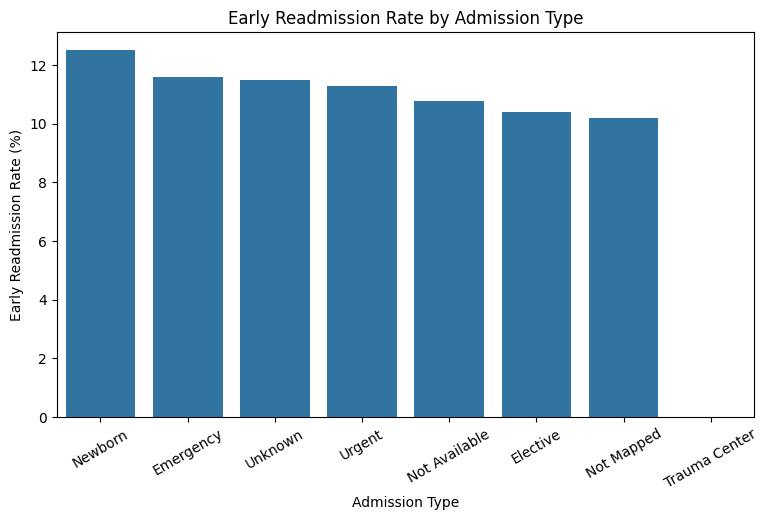

In [177]:
admission_readmission = (
    train_df.groupby("admission_type")["early_readmission"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=admission_readmission.index,
    y=admission_readmission.values
)

plt.title("Early Readmission Rate by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Early Readmission Rate (%)")
plt.xticks(rotation=30)

plt.show()

In [178]:
admission_readmission.round(2)

,early_readmission
admission_type,
Newborn,12.50
Emergency,11.61
Unknown,11.50
Urgent,11.28
Not Available,10.78
Elective,10.41
Not Mapped,10.20
Trauma Center,0.00


#### Admission Type and Early Readmission

The observed early-readmission rate varies across admission types. Among the
common admission categories, Emergency admissions have an observed rate of
11.61%, followed by Urgent admissions at 11.28% and Elective admissions at
10.41%.

The Newborn and Trauma Center categories have very few encounters (8 and 17,
respectively), making their observed rates unstable and unsuitable for strong
comparisons.

Overall, the commonly occurring admission types show relatively similar
early-readmission rates in the training data.

#### Admission Source and Early Readmission

We examine the source from which patients were admitted and compare the
observed early-readmission rates across the different admission sources.

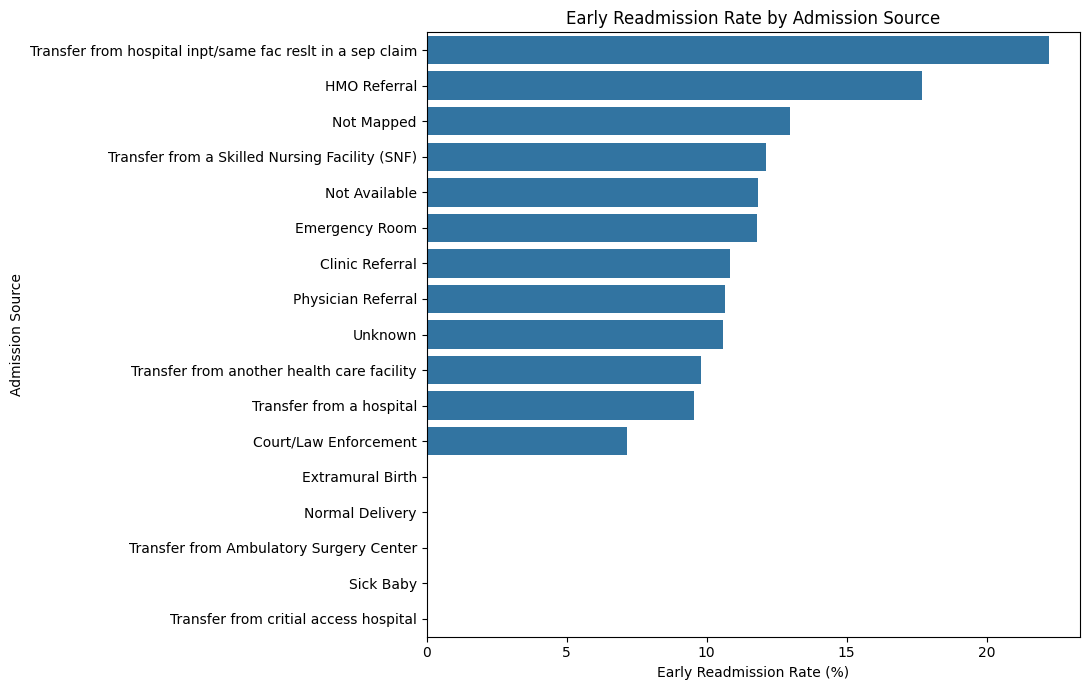

In [179]:
source_readmission = (
    train_df.groupby("admission_source")["early_readmission"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    x=source_readmission.values,
    y=source_readmission.index
)

plt.title("Early Readmission Rate by Admission Source")
plt.xlabel("Early Readmission Rate (%)")
plt.ylabel("Admission Source")

plt.tight_layout()
plt.show()

In [180]:
source_summary = pd.DataFrame({
    "encounters": train_df["admission_source"].value_counts(),
    "early_readmission_rate": train_df.groupby("admission_source")["early_readmission"].mean().mul(100)
})

source_summary = source_summary.sort_values(
    "early_readmission_rate",
    ascending=False
)

source_summary.round(2)

,encounters,early_readmission_rate
admission_source,,
Transfer from hospital inpt/same fac reslt in a sep claim,9,22.22
HMO Referral,147,17.69
Not Mapped,131,12.98
Transfer from a Skilled Nursing Facility (SNF),709,12.13
Not Available,93,11.83
Emergency Room,46005,11.81
Clinic Referral,906,10.82
Physician Referral,23603,10.64
Unknown,5477,10.57


#### Admission Source and Early Readmission

The observed early-readmission rate varies across admission sources. Emergency
Room admissions account for the largest number of encounters (46,005) and have
an observed early-readmission rate of 11.81%. Physician Referral is the second
most common source, with 23,603 encounters and an observed rate of 10.64%.

Some less frequent admission sources show higher observed rates, but these
estimates are based on very small numbers of encounters. For example, the
highest observed rate is 22.22% for `Transfer from hospital inpt/same fac reslt
in a sep claim`, but this category contains only 9 encounters.

Therefore, admission-source rates should be interpreted together with their
sample sizes rather than comparing the percentages alone.

#### Discharge Disposition and Early Readmission

We next examine the patient's discharge disposition and compare the observed
early-readmission rates across discharge categories.

Because several discharge categories are rare and have long descriptions, the
analysis considers both the number of encounters and the observed
early-readmission rate.

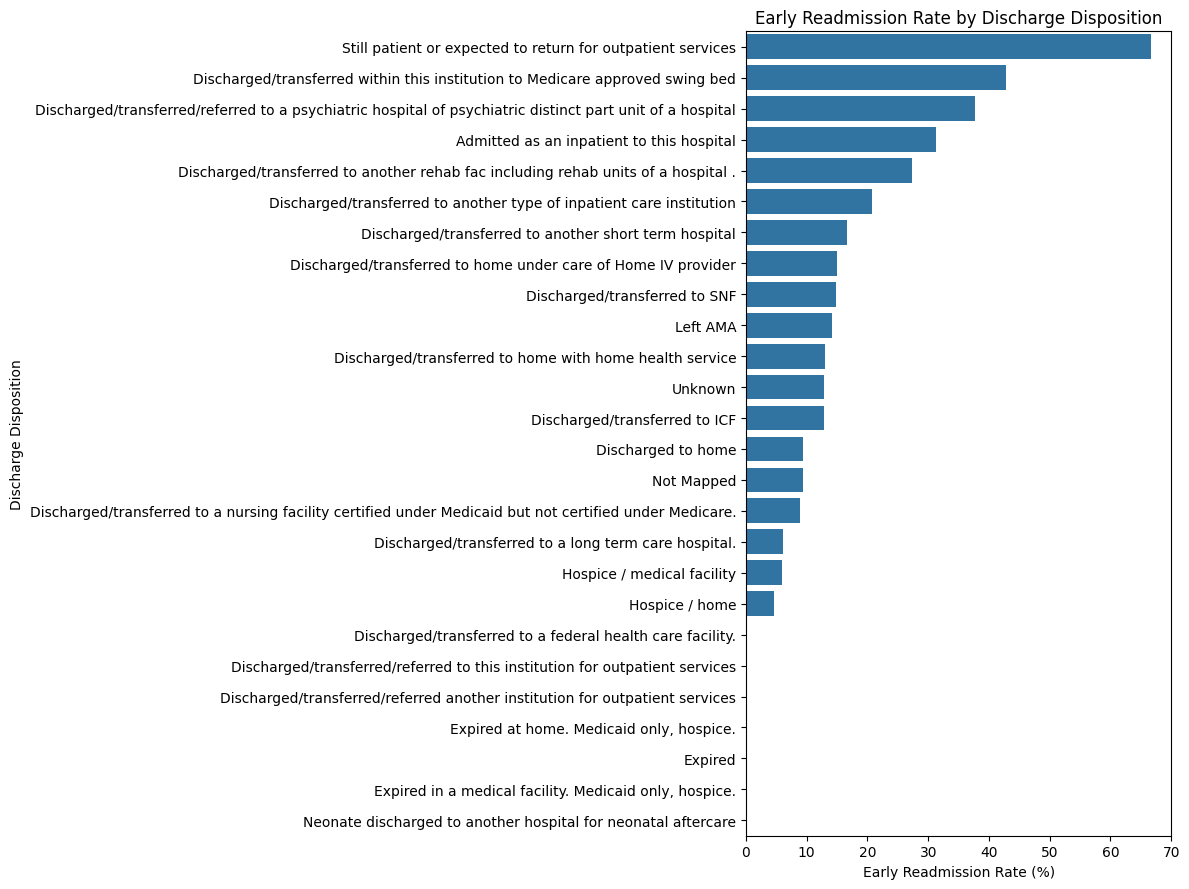

In [181]:
discharge_readmission = (
    train_df.groupby("discharge_disposition")["early_readmission"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 9))

sns.barplot(
    x=discharge_readmission.values,
    y=discharge_readmission.index
)

plt.title("Early Readmission Rate by Discharge Disposition")
plt.xlabel("Early Readmission Rate (%)")
plt.ylabel("Discharge Disposition")

plt.tight_layout()
plt.show()

In [182]:
discharge_summary = pd.DataFrame({
    "encounters": train_df["discharge_disposition"].value_counts(),
    "early_readmission_rate": (
        train_df.groupby("discharge_disposition")["early_readmission"]
        .mean()
        .mul(100)
    )
})

discharge_summary = discharge_summary.sort_values(
    "early_readmission_rate",
    ascending=False
)

discharge_summary.round(2)

,encounters,early_readmission_rate
discharge_disposition,,
Still patient or expected to return for outpatient services,3,66.67
Discharged/transferred within this institution to Medicare approved swing bed,49,42.86
Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital,122,37.70
Admitted as an inpatient to this hospital,16,31.25
Discharged/transferred to another rehab fac including rehab units of a hospital .,1594,27.35
Discharged/transferred to another type of inpatient care institution,960,20.73
Discharged/transferred to another short term hospital,1703,16.62
Discharged/transferred to home under care of Home IV provider,80,15.00
Discharged/transferred to SNF,11176,14.78


#### Discharge Disposition and Early Readmission

The observed early-readmission rate varies substantially across discharge
dispositions. Encounters discharged to home have an observed early-readmission
rate of 9.39%, while discharge to a skilled nursing facility (SNF) has a rate of
14.78%.

Several categories have substantially higher observed rates, including transfer
to another rehabilitation facility (27.35%) and transfer to another type of
inpatient care institution (20.73%). However, some categories contain very few
encounters, making their observed rates unstable.

The `Expired` category has a 0% early-readmission rate because a subsequent
early readmission cannot occur after death. Therefore, this category should
not be interpreted as evidence of lower readmission risk.

Overall, discharge disposition shows considerable variation in observed
early-readmission rates, but the differences should be interpreted together
with the number of encounters in each category.

### 7.5 Length of Hospital Stay

We examine the relationship between the number of days spent in the hospital
and early readmission. The dataset records length of stay as an integer number
of days from 1 to 14.

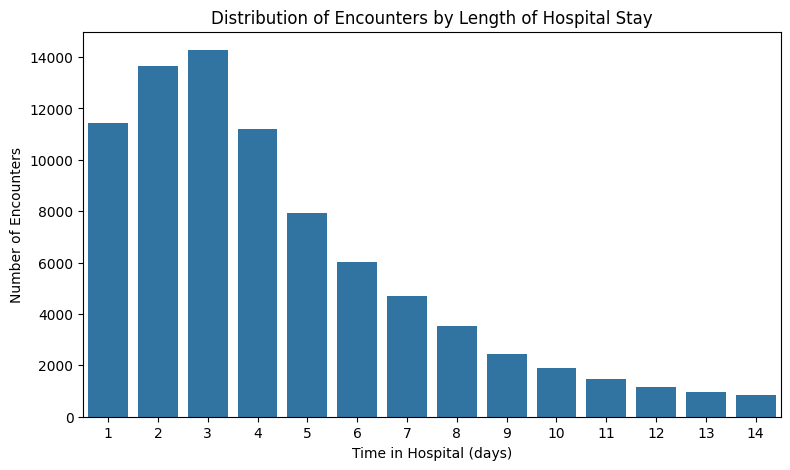

In [183]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=train_df,
    x="time_in_hospital"
)

plt.title("Distribution of Encounters by Length of Hospital Stay")
plt.xlabel("Time in Hospital (days)")
plt.ylabel("Number of Encounters")

plt.show()

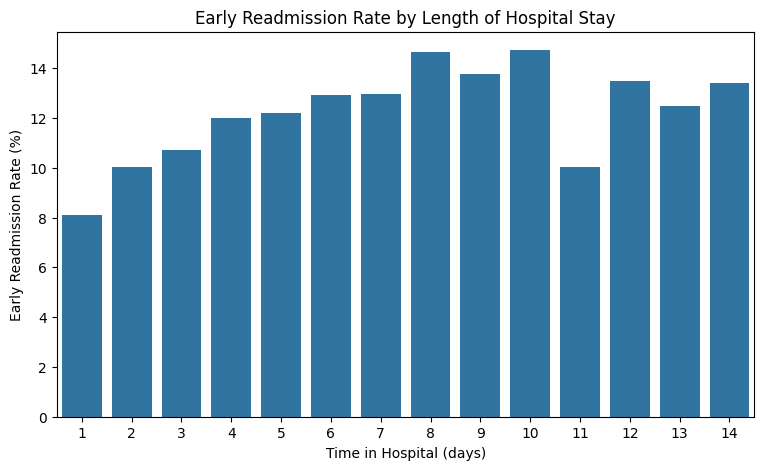

In [184]:
stay_readmission = (
    train_df.groupby("time_in_hospital")["early_readmission"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=stay_readmission.index,
    y=stay_readmission.values
)

plt.title("Early Readmission Rate by Length of Hospital Stay")
plt.xlabel("Time in Hospital (days)")
plt.ylabel("Early Readmission Rate (%)")

plt.show()

In [185]:
stay_readmission.round(2)

,early_readmission
time_in_hospital,
1,8.12
2,10.03
3,10.71
4,11.98
5,12.18
6,12.92
7,12.97
8,14.66
9,13.75


#### Length of Hospital Stay and Early Readmission

The observed early-readmission rate generally increases as length of hospital
stay increases from 1 to approximately 8–10 days. The rate rises from 8.12%
for a one-day stay to 14.66% for an eight-day stay and 14.73% for a ten-day
stay.

The relationship is not strictly monotonic, however. The rate fluctuates at
longer lengths of stay, including a drop to 10.03% for an 11-day stay.

Overall, longer hospital stays show higher observed early-readmission rates
across much of the observed range, but this represents an association and does
not establish a causal relationship.

### 7.6 Previous Healthcare Utilization

We next examine the patient's previous healthcare utilization, including
outpatient, emergency, and inpatient visits. These variables may capture prior
healthcare use before the current encounter.

#### Previous Outpatient Visits and Early Readmission

We examine the number of outpatient visits recorded for the patient before the
current encounter and compare the observed early-readmission rate across
different levels of prior outpatient utilization.

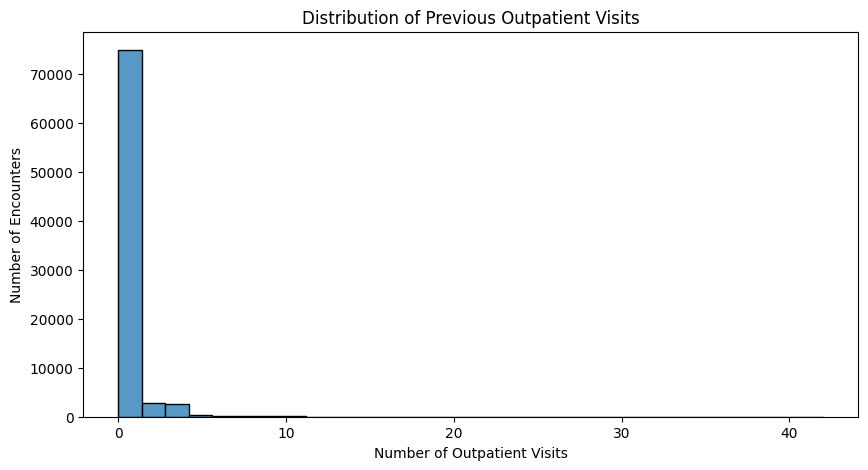

In [186]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="number_outpatient",
    bins=30
)

plt.title("Distribution of Previous Outpatient Visits")
plt.xlabel("Number of Outpatient Visits")
plt.ylabel("Number of Encounters")

plt.show()

#### Previous Outpatient Visits and Early Readmission

The number of previous outpatient visits is highly right-skewed. Most encounters
have zero recorded outpatient visits, while a small number of encounters have
substantially higher counts.

To make the relationship with early readmission easier to interpret, outpatient
visits are grouped into a few ranges for visualization. The original numerical
variable is retained unchanged for subsequent modeling.

In [187]:
outpatient_bins = [-1, 0, 2, 5, float("inf")]

outpatient_labels = ["0", "1-2", "3-5", "6+"]

for df in [train_df, test_df]:
    df["outpatient_group"] = pd.cut(
        df["number_outpatient"],
        bins=outpatient_bins,
        labels=outpatient_labels
    )

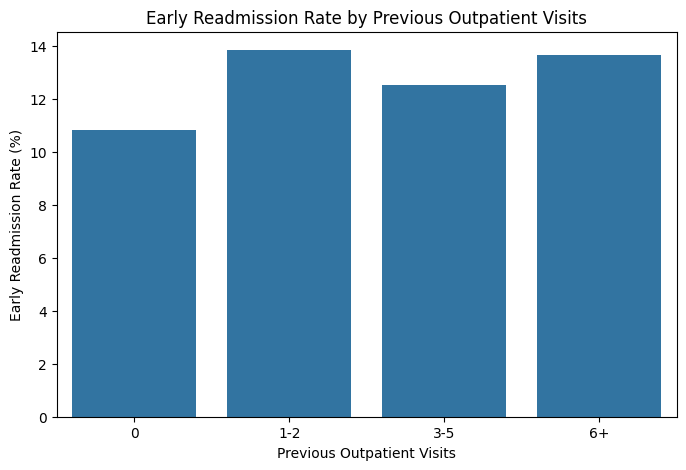

In [188]:
outpatient_readmission = (
    train_df.groupby(
        "outpatient_group",
        observed=False
    )["early_readmission"]
    .mean()
    .mul(100)
    .reindex(outpatient_labels)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=outpatient_readmission.index,
    y=outpatient_readmission.values
)

plt.title("Early Readmission Rate by Previous Outpatient Visits")
plt.xlabel("Previous Outpatient Visits")
plt.ylabel("Early Readmission Rate (%)")

plt.show()

In [189]:
outpatient_summary = pd.DataFrame({
    "encounters": outpatient_counts,
    "early_readmission_rate": outpatient_readmission
})

outpatient_summary.round(2)

,encounters,early_readmission_rate
outpatient_group,,
0,68004,10.83
1-2,9773,13.85
3-5,2969,12.53
6+,731,13.68


#### Previous Outpatient Visits and Early Readmission

Encounters with at least one previous outpatient visit show higher observed
early-readmission rates than encounters with no previous outpatient visits. The
rate is 10.83% for encounters with zero previous outpatient visits and 13.85%
for those with 1–2 previous visits.

The rates for higher levels of outpatient utilization remain in a similar
range, although the `6+` group contains relatively few encounters.

Overall, prior outpatient utilization shows an association with early
readmission in the training data, but the relationship is not strictly
monotonic.

#### Previous Emergency Visits and Early Readmission

We next examine the number of emergency visits recorded before the current
encounter and investigate its relationship with early readmission.

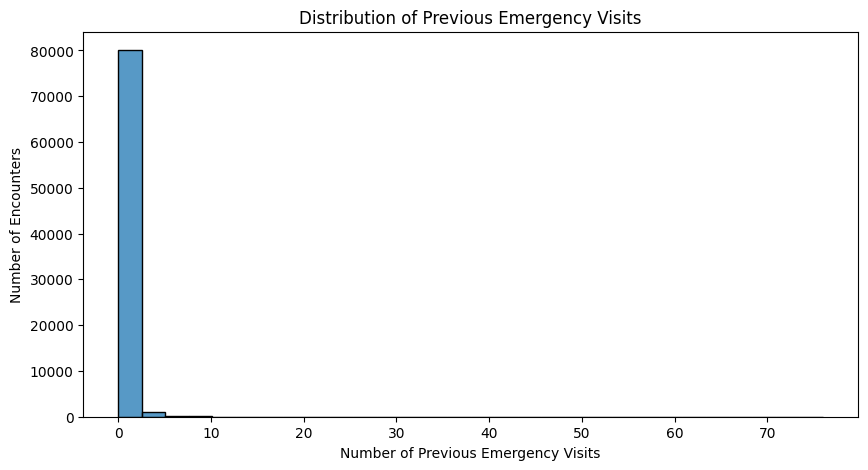

In [190]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="number_emergency",
    bins=30
)

plt.title("Distribution of Previous Emergency Visits")
plt.xlabel("Number of Previous Emergency Visits")
plt.ylabel("Number of Encounters")

plt.show()

#### Previous Emergency Visits and Early Readmission

The number of previous emergency visits is highly right-skewed. Most encounters
have no recorded previous emergency visits, while a small number have multiple
previous emergency visits.

For visualization, the variable is grouped into a few ranges to make the
relationship with early readmission easier to interpret. The original numerical
variable is retained unchanged for modeling.

In [191]:
emergency_bins = [-1, 0, 1, 3, 5, float("inf")]

emergency_labels = ["0", "1", "2-3", "4-5", "6+"]

for df in [train_df, test_df]:
    df["emergency_group"] = pd.cut(
        df["number_emergency"],
        bins=emergency_bins,
        labels=emergency_labels
    )

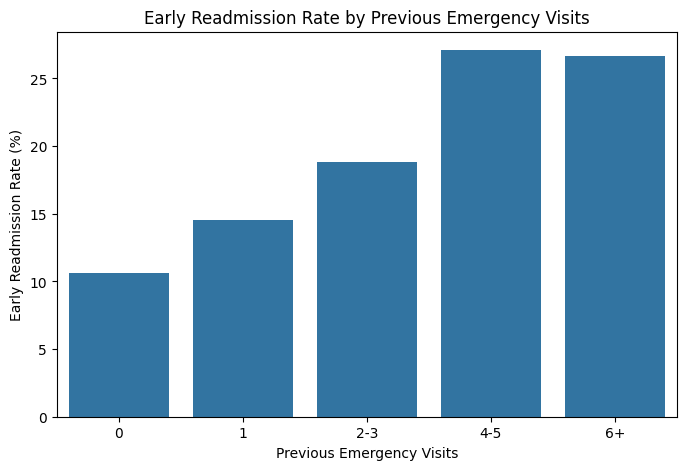

In [192]:
emergency_readmission = (
    train_df.groupby(
        "emergency_group",
        observed=False
    )["early_readmission"]
    .mean()
    .mul(100)
    .reindex(emergency_labels)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=emergency_readmission.index,
    y=emergency_readmission.values
)

plt.title("Early Readmission Rate by Previous Emergency Visits")
plt.xlabel("Previous Emergency Visits")
plt.ylabel("Early Readmission Rate (%)")

plt.show()

In [193]:
emergency_summary = pd.DataFrame({
    "encounters": emergency_counts,
    "early_readmission_rate": emergency_readmission
})

emergency_summary.round(2)

,encounters,early_readmission_rate
emergency_group,,
0,72259,10.60
1,6189,14.51
2-3,2249,18.81
4-5,476,27.10
6+,304,26.64


#### Previous Emergency Visits and Early Readmission

A clear positive association is observed between previous emergency visits and
early readmission. The early-readmission rate increases from 10.60% among
encounters with no previous emergency visits to 27.10% among encounters with
4–5 previous emergency visits.

The rate for the `6+` group is slightly lower at 26.64%, but this group contains
only 304 encounters, so its estimate should be interpreted cautiously.

Overall, higher previous emergency utilization is associated with substantially
higher observed early-readmission rates in the training data.

#### Previous Inpatient Visits and Early Readmission

We next examine the number of previous inpatient visits recorded before the
current encounter and its relationship with early readmission.

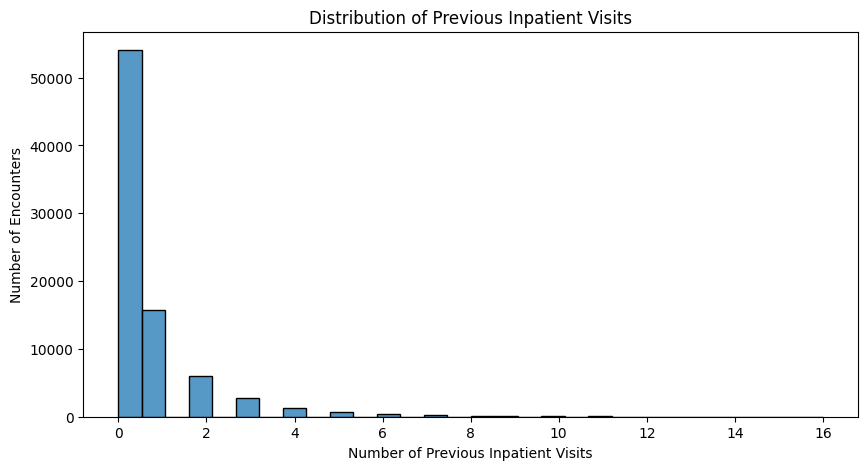

In [194]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="number_inpatient",
    bins=30
)

plt.title("Distribution of Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Number of Encounters")

plt.show()

#### Previous Inpatient Visits and Early Readmission

The number of previous inpatient visits is right-skewed, with most encounters
having zero previous inpatient visits. However, previous inpatient utilization
is more common than previous emergency utilization, with 75% of encounters
having at most one previous inpatient visit.

For visualization, previous inpatient visits are grouped into five ranges.
The original numerical variable is retained unchanged for modeling.

In [195]:
inpatient_bins = [-1, 0, 1, 3, 5, float("inf")]

inpatient_labels = ["0", "1", "2-3", "4-5", "6+"]

for df in [train_df, test_df]:
    df["inpatient_group"] = pd.cut(
        df["number_inpatient"],
        bins=inpatient_bins,
        labels=inpatient_labels
    )

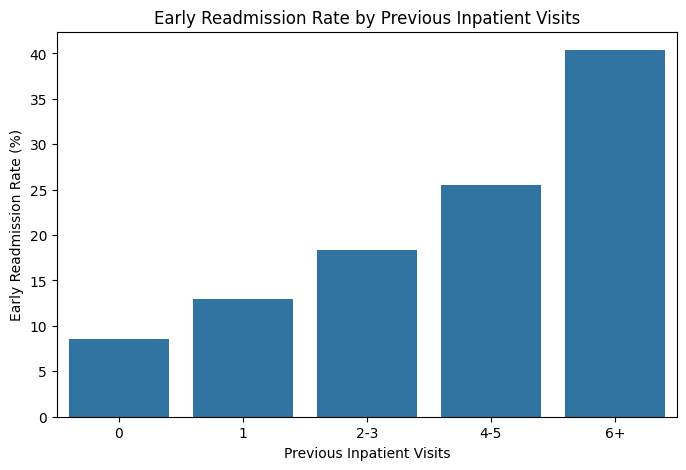

In [196]:
inpatient_readmission = (
    train_df.groupby(
        "inpatient_group",
        observed=False
    )["early_readmission"]
    .mean()
    .mul(100)
    .reindex(inpatient_labels)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=inpatient_readmission.index,
    y=inpatient_readmission.values
)

plt.title("Early Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Previous Inpatient Visits")
plt.ylabel("Early Readmission Rate (%)")

plt.show()

In [197]:
inpatient_summary = pd.DataFrame({
    "encounters": inpatient_counts,
    "early_readmission_rate": inpatient_readmission
})

inpatient_summary.round(2)

,encounters,early_readmission_rate
inpatient_group,,
0,54060,8.58
1,15689,12.97
2-3,8771,18.39
4-5,1976,25.56
6+,981,40.37


#### Previous Inpatient Visits and Early Readmission

A strong positive association is observed between previous inpatient
utilization and early readmission. The early-readmission rate increases from
8.58% among encounters with no previous inpatient visits to 40.37% among
encounters with 6 or more previous inpatient visits.

The increase is consistent across the groups: 12.97% for one previous visit,
18.39% for 2–3 visits, and 25.56% for 4–5 visits.

The `6+` group contains 981 encounters, so its exact rate should be interpreted
with some caution. Nevertheless, the overall pattern suggests that previous
inpatient utilization is strongly associated with early readmission in the
training data.

### 7.7 Diagnosis Features

The dataset contains up to three diagnosis codes for each encounter. Rather
than treating every individual ICD-9 code as a separate category, we first
examine the structure and frequency of the diagnosis codes.

The goal is to determine whether the codes can be transformed into broader,
meaningful diagnostic categories for modeling.

In [198]:
diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_cols:
    print(f"\n--- {col} ---")
    print("Unique codes:", train_df[col].nunique())
    print("Missing/unknown:", (train_df[col] == "?").sum())
    print("Top 15 codes:")
    print(train_df[col].value_counts().head(15))


--- diag_1 ---
Unique codes: 697
Missing/unknown: 0
Top 15 codes:
diag_1
428      5450
414      5250
786      3207
410      2871
486      2805
427      2253
491      1810
715      1717
434      1639
780      1632
996      1610
682      1592
276      1525
250.8    1351
38       1323
Name: count, dtype: int64

--- diag_2 ---
Unique codes: 715
Missing/unknown: 0
Top 15 codes:
diag_2
276       5501
428       5322
250       4837
427       4104
401       3014
496       2663
599       2604
403       2302
414       2141
411       2044
250.02    1631
707       1597
585       1524
584       1306
491       1238
Name: count, dtype: int64

--- diag_3 ---
Unique codes: 752
Missing/unknown: 0
Top 15 codes:
diag_3
250        9276
401        6670
276        4152
428        3665
427        3224
414        2925
496        2071
403        1894
585        1599
272        1588
599        1543
V45        1144
Unknown    1136
707        1107
250.02     1100
Name: count, dtype: int64


### Diagnosis Code Grouping

The diagnosis variables contain hundreds of individual ICD-9 codes, including
numeric diagnosis codes, V-codes, and E-codes. Using every individual code
directly would create a high-cardinality feature space.

To reduce dimensionality while retaining clinical information, diagnosis codes
are grouped into broader ICD-9 categories based on their code ranges.
V-codes and E-codes are retained as separate categories, while unknown or
unrecognized codes are assigned to an `Unknown` category.

In [199]:
def categorize_diagnosis(code):
    code = str(code).strip()

    # Handle V and E codes
    if code.startswith("V"):
        return "V_code"

    if code.startswith("E"):
        return "E_code"

    # Handle unknown values
    if code in ["?", "Unknown", "nan", "NaN"]:
        return "Unknown"

    try:
        num = float(code)
    except ValueError:
        return "Unknown"

    # ICD-9-CM broad disease categories
    if 1 <= num <= 139:
        return "Infectious"
    elif 140 <= num <= 239:
        return "Neoplasms"
    elif 240 <= num <= 279:
        return "Endocrine_Metabolic"
    elif 280 <= num <= 289:
        return "Blood"
    elif 290 <= num <= 319:
        return "Mental"
    elif 320 <= num <= 359:
        return "Nervous"
    elif 360 <= num <= 389:
        return "Sense_Organs"
    elif 390 <= num <= 459:
        return "Circulatory"
    elif 460 <= num <= 519:
        return "Respiratory"
    elif 520 <= num <= 579:
        return "Digestive"
    elif 580 <= num <= 629:
        return "Genitourinary"
    elif 630 <= num <= 679:
        return "Pregnancy"
    elif 680 <= num <= 709:
        return "Skin"
    elif 710 <= num <= 739:
        return "Musculoskeletal"
    elif 740 <= num <= 759:
        return "Congenital"
    elif 760 <= num <= 779:
        return "Perinatal"
    elif 780 <= num <= 799:
        return "Symptoms_Signs"
    elif 800 <= num <= 999:
        return "Injury_Poisoning"
    else:
        return "Unknown"

In [200]:
for col in diagnosis_cols:
    train_df[f"{col}_group"] = train_df[col].apply(categorize_diagnosis)
    test_df[f"{col}_group"] = test_df[col].apply(categorize_diagnosis)

In [201]:
for col in diagnosis_cols:
    group_col = f"{col}_group"

    print(f"\n--- {group_col} ---")
    print(train_df[group_col].value_counts())


--- diag_1_group ---
diag_1_group
Circulatory            24307
Endocrine_Metabolic     9218
Respiratory             8304
Digestive               7431
Symptoms_Signs          6125
Injury_Poisoning        5626
Genitourinary           4104
Musculoskeletal         3941
Neoplasms               2714
Infectious              2180
Skin                    1976
Mental                  1832
V_code                  1277
Blood                    883
Nervous                  756
Pregnancy                532
Sense_Organs             212
Congenital                43
Unknown                   15
E_code                     1
Name: count, dtype: int64

--- diag_2_group ---
diag_2_group
Circulatory            25182
Endocrine_Metabolic    16827
Respiratory             8208
Genitourinary           6368
Symptoms_Signs          3729
Digestive               3165
Skin                    2885
Blood                   2287
Mental                  2145
Neoplasms               2006
Injury_Poisoning        1936
Infec

### Diagnosis Groups and Early Readmission

We examine whether broad diagnosis categories are associated with early
readmission. Diagnosis codes are considered in their primary, secondary, and
tertiary positions separately because the position of a diagnosis may carry
different clinical meaning.

In [202]:
for col in ["diag_1_group", "diag_2_group", "diag_3_group"]:

    result = (
        train_df.groupby(col)["early_readmission"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    result["rate"] = result["mean"] * 100

    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'='*60}")
    print(result[["count", "rate"]].round(2))


diag_1_group
                     count   rate
diag_1_group                     
Unknown                 15  20.00
V_code                1277  15.90
Blood                  883  13.25
Endocrine_Metabolic   9218  13.00
Mental                1832  12.72
Injury_Poisoning      5626  12.41
Nervous                756  12.30
Circulatory          24307  11.58
Infectious            2180  11.10
Genitourinary         4104  11.01
Digestive             7431  10.83
Respiratory           8304  10.67
Skin                  1976   9.92
Neoplasms             2714   9.65
Musculoskeletal       3941   9.39
Congenital              43   9.30
Symptoms_Signs        6125   9.29
Pregnancy              532   6.39
Sense_Organs           212   4.25
E_code                   1   0.00

diag_2_group
                     count   rate
diag_2_group                     
Neoplasms             2006  14.46
Skin                  2885  14.00
E_code                 608  13.98
Nervous                910  13.41
Genitourinary       

### Diagnosis Group vs Early Readmission Rate

Diagnosis groups with sufficient observations are compared using their
early-readmission rates. Very small groups are excluded from the visualization
to avoid over-interpreting unstable rates.

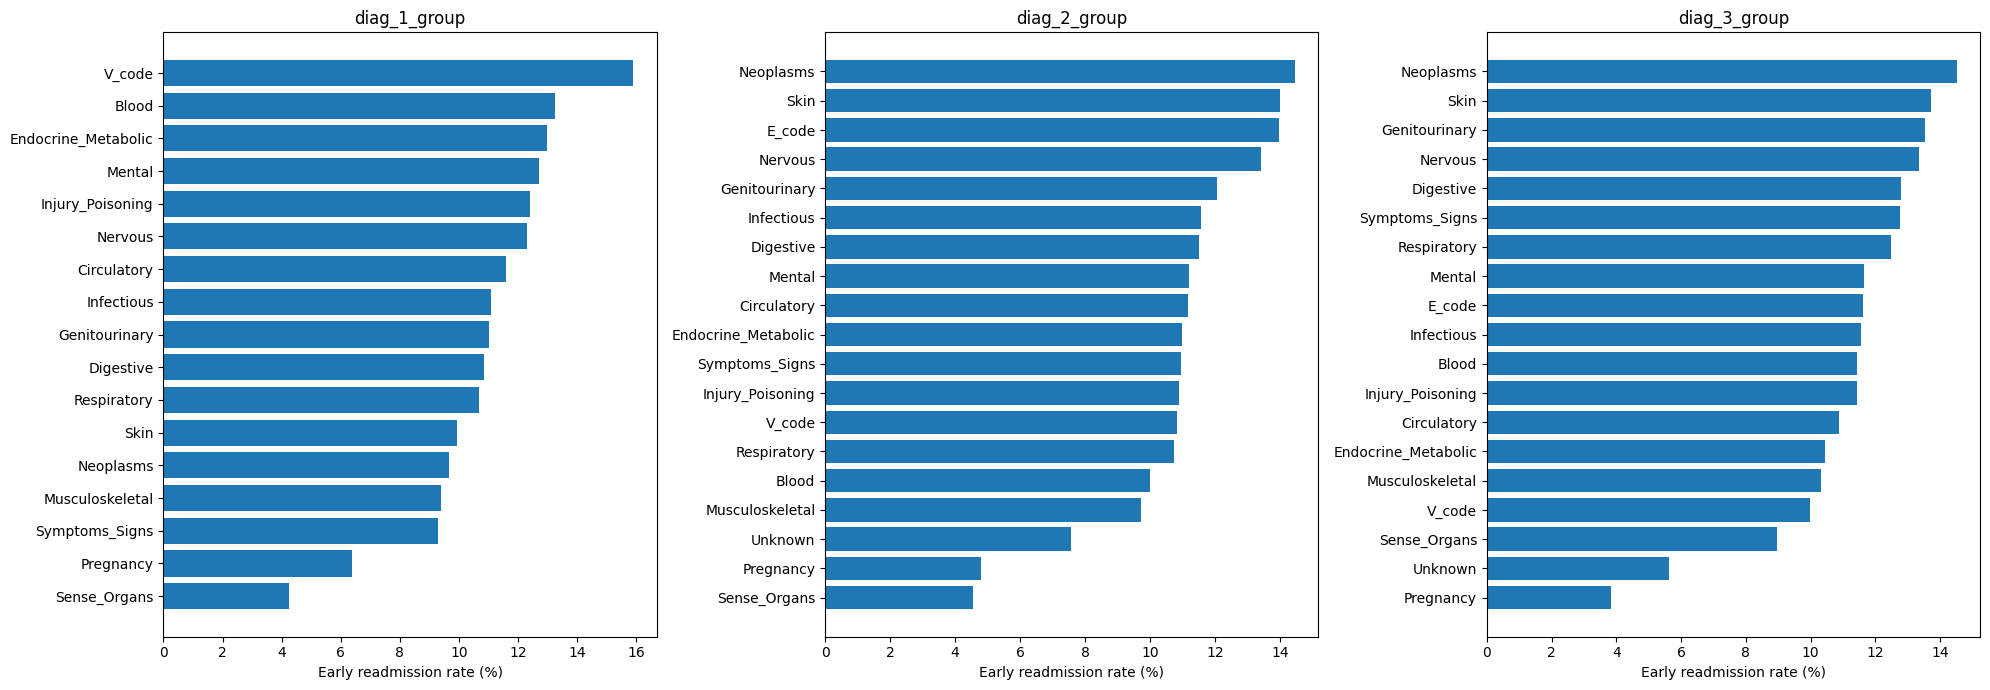

In [203]:
diagnosis_cols = ["diag_1_group", "diag_2_group", "diag_3_group"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, col in zip(axes, diagnosis_cols):

    result = (
        train_df.groupby(col)["early_readmission"]
        .agg(["count", "mean"])
        .query("count >= 100")
        .sort_values("mean", ascending=True)
    )

    result["rate"] = result["mean"] * 100

    ax.barh(result.index, result["rate"])
    ax.set_title(col)
    ax.set_xlabel("Early readmission rate (%)")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Medication Features

The dataset contains multiple diabetes medication variables. Each medication
records whether the medication was not prescribed (`No`), continued at a
steady dose (`Steady`), increased (`Up`), or decreased (`Down`).

We first examine their overall usage and variation before deciding which
medication features require further analysis.

In [204]:
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

medication_summary = []

for col in medication_cols:
    counts = train_df[col].value_counts()

    medication_summary.append({
        "medication": col,
        "used": (train_df[col] != "No").sum(),
        "usage_pct": (train_df[col] != "No").mean() * 100,
        "up": counts.get("Up", 0),
        "down": counts.get("Down", 0),
        "steady": counts.get("Steady", 0)
    })

medication_summary = pd.DataFrame(medication_summary)

medication_summary.sort_values(
    "usage_pct",
    ascending=False
).round(2)

,medication,used,usage_pct,up,down,steady
17,insulin,43496,53.38,9011,9739,24746
0,metformin,15928,19.55,853,455,14620
6,glipizide,10267,12.60,633,453,9181
7,glyburide,8565,10.51,632,455,7478
9,pioglitazone,5854,7.18,184,91,5579
10,rosiglitazone,5079,6.23,144,64,4871
4,glimepiride,4159,5.10,268,162,3729
1,repaglinide,1221,1.50,90,40,1091
2,nateglinide,555,0.68,24,6,525
18,glyburide-metformin,551,0.68,6,5,540


### Medication Status and Early Readmission

We examine whether medication status is associated with early readmission for
the most frequently used diabetes medications. Rare medications are not
analyzed individually because their small sample sizes would produce unstable
comparisons.

In [205]:
important_medications = [
    "insulin",
    "metformin",
    "glipizide",
    "glyburide",
    "pioglitazone",
    "rosiglitazone",
    "glimepiride"
]

for col in important_medications:

    result = (
        train_df.groupby(col)["early_readmission"]
        .agg(["count", "mean"])
    )

    result["rate"] = result["mean"] * 100

    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    print(result[["count", "rate"]].round(2))


insulin
         count   rate
insulin              
Down      9739  14.11
No       37981  10.19
Steady   24746  11.25
Up        9011  12.84

metformin
           count   rate
metformin              
Down         455  13.41
No         65549  11.65
Steady     14620   9.71
Up           853   8.44

glipizide
           count   rate
glipizide              
Down         453  15.67
No         71210  11.19
Steady      9181  11.63
Up           633  13.11

glyburide
           count   rate
glyburide              
Down         455   9.45
No         72912  11.34
Steady      7478  10.87
Up           632  10.44

pioglitazone
              count   rate
pioglitazone              
Down             91  14.29
No            75623  11.34
Steady         5579  10.41
Up              184  10.33

rosiglitazone
               count   rate
rosiglitazone              
Down              64   7.81
No             76398  11.32
Steady          4871  10.55
Up               144  11.81

glimepiride
             count   r

### Medication Status vs Early Readmission

The early-readmission rate is compared across medication status categories for
the most frequently used diabetes medications. This provides a compact view of
whether medication status contains potentially useful predictive information.

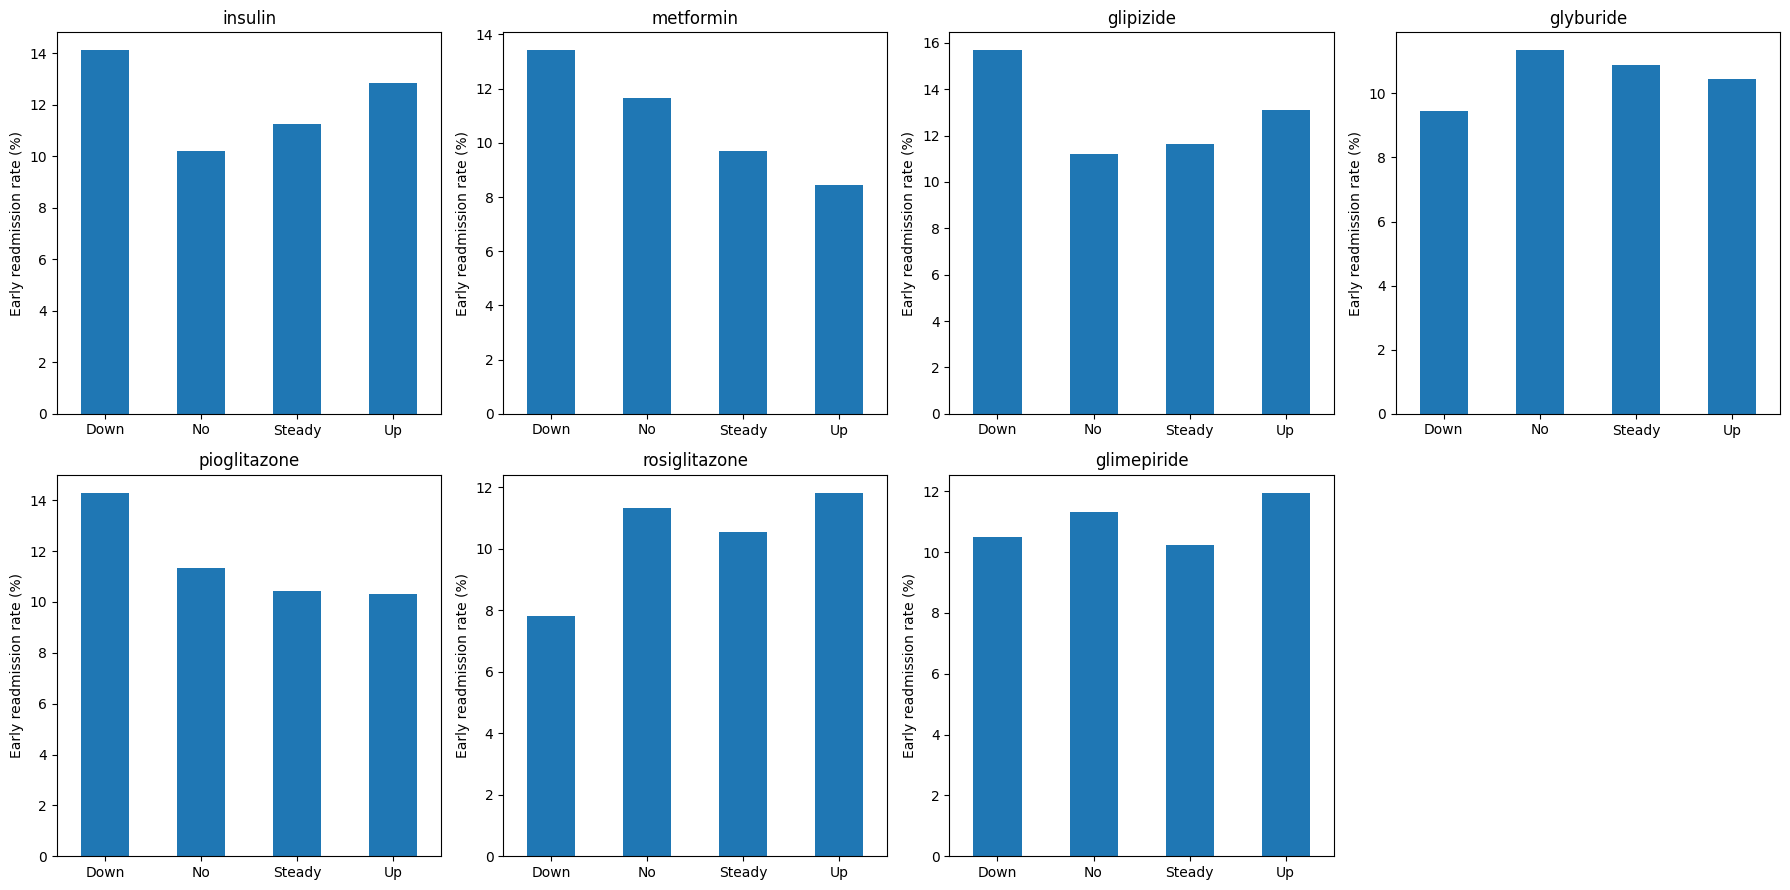

In [206]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, important_medications):

    result = (
        train_df.groupby(col)["early_readmission"]
        .mean()
        .mul(100)
    )

    result.plot(kind="bar", ax=ax)

    ax.set_title(col)
    ax.set_ylabel("Early readmission rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### Diabetes Medication Management and Early Readmission

We examine whether the overall use of diabetes medication and whether
medication therapy was changed during the encounter are associated with
early readmission.

In [207]:
medication_management_cols = ["change", "diabetesMed"]

for col in medication_management_cols:

    result = (
        train_df.groupby(col)["early_readmission"]
        .agg(["count", "mean"])
    )

    result["rate"] = result["mean"] * 100

    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    print(result[["count", "rate"]].round(2))


change
        count   rate
change              
Ch      37641  11.87
No      43836  10.77

diabetesMed
             count   rate
diabetesMed              
No           18798   9.82
Yes          62679  11.71


### Clinical and Treatment Utilization Features

We examine the distributions of laboratory procedures, procedures,
medications, and diagnoses, and their relationship with early readmission.
These variables describe the intensity and complexity of care during the
hospital encounter.

In [208]:
clinical_numeric_cols = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

for col in clinical_numeric_cols:

    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")

    print(train_df[col].describe())

    print("\nEarly readmission by value:")
    result = (
        train_df.groupby(col)["early_readmission"]
        .agg(["count", "mean"])
    )

    result["rate"] = result["mean"] * 100

    print(result[["count", "rate"]].round(2).head(20))


num_lab_procedures
count    81477.000000
mean        43.111516
std         19.654359
min          1.000000
25%         31.000000
50%         44.000000
75%         57.000000
max        132.000000
Name: num_lab_procedures, dtype: float64

Early readmission by value:
                    count   rate
num_lab_procedures              
1                    2535   9.39
2                     872  10.89
3                     537   8.94
4                     289   6.92
5                     224   9.38
6                     220   6.82
7                     261   6.90
8                     295   7.12
9                     760  12.37
10                    660  11.52
11                    559   9.30
12                    415   9.88
13                    311   9.32
14                    258  12.02
15                    372  11.83
16                    442  12.44
17                    591   9.31
18                    596  10.07
19                    788  10.03
20                    624   8.97

num_pro

## Early Readmission by Number of Medications

Since `num_medications` has many distinct values, we group encounters into ranges to make the relationship with early readmission easier to interpret.

In [209]:
med_bins = [0, 5, 10, 15, 20, 30, float("inf")]

med_labels = ["1-5", "6-10", "11-15", "16-20", "21-30", "31+"]

train_df["medication_group"] = pd.cut(
    train_df["num_medications"],
    bins=med_bins,
    labels=med_labels,
    include_lowest=True
)

test_df["medication_group"] = pd.cut(
    test_df["num_medications"],
    bins=med_bins,
    labels=med_labels,
    include_lowest=True
)

med_analysis = (
    train_df.groupby("medication_group", observed=True)["early_readmission"]
    .agg(["count", "mean"])
)

med_analysis["rate"] = med_analysis["mean"] * 100

med_analysis = med_analysis.drop(columns="mean")

med_analysis

,count,rate
medication_group,,
1-5,4033,7.760972
6-10,16608,9.621869
11-15,23585,11.096036
16-20,18182,12.193378
21-30,14876,12.879806
31+,4193,12.568567


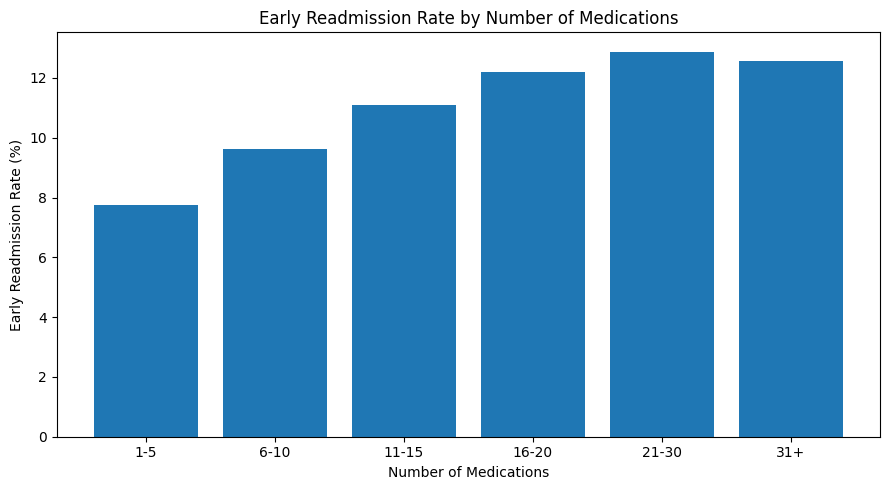

In [210]:
plt.figure(figsize=(9, 5))

plt.bar(
    med_analysis.index.astype(str),
    med_analysis["rate"]
)

plt.xlabel("Number of Medications")
plt.ylabel("Early Readmission Rate (%)")
plt.title("Early Readmission Rate by Number of Medications")

plt.tight_layout()
plt.show()

## Early Readmission by Number of Diagnoses

We examine whether the number of recorded diagnoses during an encounter is associated with early readmission. Higher diagnosis counts are grouped to avoid drawing conclusions from very small groups.

In [211]:
diagnosis_bins = [0, 3, 5, 7, 9, float("inf")]

diagnosis_labels = ["1-3", "4-5", "6-7", "8-9", "10+"]

train_df["diagnosis_group"] = pd.cut(
    train_df["number_diagnoses"],
    bins=diagnosis_bins,
    labels=diagnosis_labels,
    include_lowest=True
)

test_df["diagnosis_group"] = pd.cut(
    test_df["number_diagnoses"],
    bins=diagnosis_bins,
    labels=diagnosis_labels,
    include_lowest=True
)

diagnosis_analysis = (
    train_df.groupby("diagnosis_group", observed=True)["early_readmission"]
    .agg(["count", "mean"])
)

diagnosis_analysis["rate"] = diagnosis_analysis["mean"] * 100

diagnosis_analysis = diagnosis_analysis.drop(columns="mean")

diagnosis_analysis

,count,rate
diagnosis_group,,
1-3,3218,6.960845
4-5,13514,8.946278
6-7,16435,10.794037
8-9,48219,12.374790
10+,91,15.384615


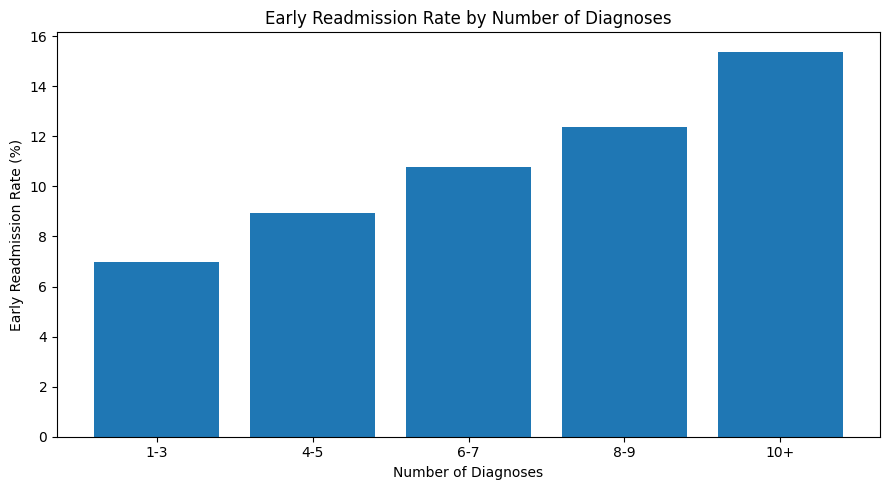

In [212]:
plt.figure(figsize=(9, 5))

plt.bar(
    diagnosis_analysis.index.astype(str),
    diagnosis_analysis["rate"]
)

plt.xlabel("Number of Diagnoses")
plt.ylabel("Early Readmission Rate (%)")
plt.title("Early Readmission Rate by Number of Diagnoses")

plt.tight_layout()
plt.show()

## Numerical Feature Distributions

We inspect the distributions of the main numerical encounter-level features to identify skewness, concentration of values, and potential outliers before feature engineering.

In [213]:
numerical_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

train_df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,81477.0,4.399094,2.986673,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,81477.0,43.111516,19.654359,1.0,31.0,44.0,57.0,132.0
num_procedures,81477.0,1.334843,1.699094,0.0,0.0,1.0,2.0,6.0
num_medications,81477.0,16.020914,8.127979,1.0,10.0,15.0,20.0,81.0
number_outpatient,81477.0,0.369736,1.254609,0.0,0.0,0.0,0.0,42.0
number_emergency,81477.0,0.201971,0.961763,0.0,0.0,0.0,0.0,76.0
number_inpatient,81477.0,0.639137,1.270576,0.0,0.0,0.0,1.0,16.0
number_diagnoses,81477.0,7.428023,1.931046,1.0,6.0,8.0,9.0,16.0


In [214]:
train_df[numerical_cols].skew().sort_values(ascending=False)

,0
number_emergency,24.116927
number_outpatient,8.648401
number_inpatient,3.587683
num_medications,1.328999
num_procedures,1.320644
time_in_hospital,1.131938
num_lab_procedures,-0.232627
number_diagnoses,-0.879557


# 8. Feature and Target Selection

We now prepare the final feature matrix for machine learning.

Identifier columns and outcome-related columns are excluded to prevent
data leakage, while the remaining clinical, demographic, utilization,
diagnosis, medication, and admission-related features are retained.

In [215]:
target = "early_readmission"

drop_cols = [
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

X_train = train_df.drop(columns=drop_cols + [target])
y_train = train_df[target]

X_test = test_df.drop(columns=drop_cols + [target])
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (81477, 50)
X_test shape: (20289, 50)
y_train shape: (81477,)
y_test shape: (20289,)


# 9. Data Preprocessing

The dataset contains both numerical and categorical features.

Numerical features can be used directly by suitable models, while
categorical features need to be converted into a numerical representation.

Preprocessing will be fitted only on the training data to prevent
information from the validation or test sets from leaking into the model.

In [216]:
# Identify numerical and categorical features

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Number of numerical features:", len(numerical_cols))
print("Number of categorical features:", len(categorical_cols))

print("\nNumerical features:")
print(numerical_cols)

print("\nCategorical features:")
print(categorical_cols)

Number of numerical features: 8
Number of categorical features: 39

Numerical features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'outpatient_group', 'emergency_group', 'inpatient_group', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'medication_group', 'diagnosis_group']


In [217]:
# Check cardinality of categorical features

cardinality = (
    X_train[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
)

print(cardinality)

diag_3                      752
diag_2                      715
diag_1                      697
diag_1_group                 20
diag_2_group                 20
diag_3_group                 20
age                          10
race                          6
medication_group              6
diagnosis_group               5
emergency_group               5
inpatient_group               5
metformin                     4
glyburide-metformin           4
repaglinide                   4
miglitol                      4
nateglinide                   4
glimepiride                   4
glipizide                     4
glyburide                     4
acarbose                      4
rosiglitazone                 4
pioglitazone                  4
insulin                       4
outpatient_group              4
gender                        3
tolazamide                    3
chlorpropamide                3
acetohexamide                 2
troglitazone                  2
tolbutamide                   2
change  

In [218]:
# Check missing values

missing_values = X_train.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

print("Features with missing values:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Features with missing values:
Series([], dtype: int64)

Total missing values: 0


In [219]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_cols
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [220]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (81477, 2349)
Processed X_test shape: (20289, 2349)


In [221]:
print("Processed training matrix:")
print("Shape:", X_train_processed.shape)
print("Type:", type(X_train_processed))
print("Number of non-zero values:", X_train_processed.nnz)

Processed training matrix:
Shape: (81477, 2349)
Type: <class 'scipy.sparse._csr.csr_matrix'>
Number of non-zero values: 3597754


# 10. Handling Class Imbalance

The target variable is imbalanced, with early readmission cases representing
approximately 11% of the training data.

Because predicting the minority class correctly is important, accuracy alone
is not sufficient for evaluating the models.

For models that support it, class weighting will be used to give greater
importance to the minority class during training.

In [222]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

Training target distribution:
early_readmission
0    72289
1     9188
Name: count, dtype: int64

Training target proportions:
early_readmission
0    0.887232
1    0.112768
Name: proportion, dtype: float64


# 11. Baseline Model

We begin with Logistic Regression as a simple baseline model.

Logistic Regression is useful as a baseline because it is fast,
interpretable, and provides a reference point for evaluating more
complex models.

Class weighting is used to account for the imbalance in the target
variable.

In [223]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Training set:", X_tr.shape)
print("Validation set:", X_val.shape)
print("Training target distribution:")
print(y_tr.value_counts())
print("\nValidation target distribution:")
print(y_val.value_counts())

Training set: (65181, 2349)
Validation set: (16296, 2349)
Training target distribution:
early_readmission
0    57831
1     7350
Name: count, dtype: int64

Validation target distribution:
early_readmission
0    14458
1     1838
Name: count, dtype: int64


In [224]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_tr, y_tr)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


# 12. Model Evaluation

Since the target variable is imbalanced, accuracy alone is not sufficient
to evaluate the model.

We will use ROC-AUC, PR-AUC, precision, recall, and F1-score to evaluate
the baseline model. The confusion matrix will also be used to understand
the types of classification errors made by the model.

In [225]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

y_val_pred = baseline_model.predict(X_val)
y_val_prob = baseline_model.predict_proba(X_val)[:, 1]

In [226]:
roc_auc = roc_auc_score(y_val, y_val_prob)
pr_auc = average_precision_score(y_val, y_val_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

ROC-AUC: 0.6281
PR-AUC:  0.1850

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.66      0.76     14458
           1       0.16      0.53      0.25      1838

    accuracy                           0.64     16296
   macro avg       0.54      0.59      0.51     16296
weighted avg       0.83      0.64      0.71     16296

Confusion Matrix:
[[9491 4967]
 [ 868  970]]


# 13.1 Model Improvement and Comparison

Logistic Regression provides a useful linear baseline, but relationships
between clinical, utilization, diagnosis, and medication features may be
nonlinear.

We therefore evaluate a tree-based model to determine whether it can
capture patterns that the linear baseline misses.

The validation set will be used for comparison, while the held-out test
set remains untouched.

In [227]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_tr, y_tr)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [228]:
rf_val_pred = rf_model.predict(X_val)
rf_val_prob = rf_model.predict_proba(X_val)[:, 1]

rf_roc_auc = roc_auc_score(y_val, rf_val_prob)
rf_pr_auc = average_precision_score(y_val, rf_val_prob)

print(f"ROC-AUC: {rf_roc_auc:.4f}")
print(f"PR-AUC:  {rf_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, rf_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, rf_val_pred))

ROC-AUC: 0.6348
PR-AUC:  0.1982

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14458
           1       0.79      0.01      0.01      1838

    accuracy                           0.89     16296
   macro avg       0.84      0.50      0.48     16296
weighted avg       0.88      0.89      0.84     16296

Confusion Matrix:
[[14455     3]
 [ 1827    11]]


In [229]:
model_comparison = {
    "Logistic Regression": {
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    },
    "Random Forest": {
        "ROC-AUC": rf_roc_auc,
        "PR-AUC": rf_pr_auc
    }
}

for model, metrics in model_comparison.items():
    print(model)
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print(f"  PR-AUC:  {metrics['PR-AUC']:.4f}")

Logistic Regression
  ROC-AUC: 0.6281
  PR-AUC:  0.1850
Random Forest
  ROC-AUC: 0.6348
  PR-AUC:  0.1982


# 13.2 Model Improvement and Comparison

Additional tree-based models are evaluated to determine whether they can
capture nonlinear relationships and improve upon the baseline Logistic
Regression model.

In [230]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_tr, y_tr)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [231]:
xgb_val_pred = xgb_model.predict(X_val)
xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]

xgb_roc_auc = roc_auc_score(y_val, xgb_val_prob)
xgb_pr_auc = average_precision_score(y_val, xgb_val_prob)

print(f"ROC-AUC: {xgb_roc_auc:.4f}")
print(f"PR-AUC:  {xgb_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, xgb_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, xgb_val_pred))

ROC-AUC: 0.6497
PR-AUC:  0.2049

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14458
           1       0.60      0.01      0.03      1838

    accuracy                           0.89     16296
   macro avg       0.74      0.51      0.48     16296
weighted avg       0.86      0.89      0.84     16296

Confusion Matrix:
[[14442    16]
 [ 1814    24]]


In [232]:
negative_count = (y_tr == 0).sum()
positive_count = (y_tr == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative:", negative_count)
print("Positive:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Negative: 57831
Positive: 7350
scale_pos_weight: 7.868163265306123


In [233]:
xgb_balanced = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_balanced.fit(X_tr, y_tr)

print("Balanced XGBoost trained successfully.")

Balanced XGBoost trained successfully.


In [234]:
xgb_balanced_pred = xgb_balanced.predict(X_val)
xgb_balanced_prob = xgb_balanced.predict_proba(X_val)[:, 1]

xgb_balanced_roc_auc = roc_auc_score(y_val, xgb_balanced_prob)
xgb_balanced_pr_auc = average_precision_score(y_val, xgb_balanced_prob)

print(f"ROC-AUC: {xgb_balanced_roc_auc:.4f}")
print(f"PR-AUC:  {xgb_balanced_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, xgb_balanced_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, xgb_balanced_pred))

ROC-AUC: 0.6431
PR-AUC:  0.2021

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     14458
           1       0.17      0.49      0.25      1838

    accuracy                           0.68     16296
   macro avg       0.54      0.60      0.52     16296
weighted avg       0.83      0.68      0.73     16296

Confusion Matrix:
[[10150  4308]
 [  940   898]]


# 13.3 Model Improvement and Comparison — Classification Threshold

The default classification threshold of 0.5 is not necessarily appropriate
for an imbalanced prediction problem.

The model produces a probability of early readmission, and the classification
threshold determines when that probability is converted into a class prediction.

We therefore examine different thresholds to understand the trade-off between
precision and recall for the positive class.

In [235]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}")

for threshold in thresholds:
    pred = (xgb_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, pred)
    recall = recall_score(y_val, pred)
    f1 = f1_score(y_val, pred)

    print(f"{threshold:<12.2f}{precision:<12.3f}{recall:<12.3f}{f1:<12.3f}")

Threshold   Precision   Recall      F1          
0.10        0.160       0.655       0.257       
0.15        0.205       0.331       0.253       
0.20        0.253       0.170       0.203       
0.25        0.305       0.095       0.145       
0.30        0.354       0.061       0.105       
0.35        0.416       0.040       0.073       
0.40        0.520       0.028       0.054       
0.45        0.583       0.019       0.037       
0.50        0.600       0.013       0.026       


In [236]:
import numpy as np

print("Validation probability summary:")
print(np.percentile(
    xgb_val_prob,
    [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
))

Validation probability summary:
[0.01989639 0.03475643 0.04656112 0.05591816 0.07224401 0.09597552
 0.1316896  0.183946   0.22454508 0.35918786 0.76668704]


### Classification Threshold Analysis

The predicted probabilities are concentrated below 0.5, making the default
classification threshold unsuitable for this model.

We therefore examine the precision-recall trade-off across all possible
thresholds rather than relying on the default 0.5 threshold.

In [237]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    xgb_val_prob
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best F1 threshold: {best_threshold:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")
print(f"F1-score:  {best_f1:.4f}")

Best F1 threshold: 0.1160
Precision: 0.1752
Recall:    0.5277
F1-score:  0.2631


# 14. Final Model and Test Evaluation

XGBoost achieved the strongest validation ROC-AUC and PR-AUC among the
models evaluated.

The validation set was used to select a classification threshold of 0.116
based on the F1-score. The held-out test set has not been used during model
selection and will now be evaluated once using the selected model and
threshold.

This provides an unbiased estimate of the model's performance on unseen
patients.

In [238]:
# Predict probabilities for the untouched test set
y_test_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

# Use the threshold selected from validation data
final_threshold = best_threshold

y_test_pred = (y_test_prob >= final_threshold).astype(int)

print("Final threshold:", final_threshold)

Final threshold: 0.11602018


In [239]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

test_roc_auc = roc_auc_score(y_test, y_test_prob)
test_pr_auc = average_precision_score(y_test, y_test_prob)

print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC:  {test_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Test ROC-AUC: 0.6582
Test PR-AUC:  0.2028

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.69      0.79     18120
           1       0.17      0.54      0.26      2169

    accuracy                           0.67     20289
   macro avg       0.55      0.61      0.53     20289
weighted avg       0.85      0.67      0.73     20289

Confusion Matrix:
[[12493  5627]
 [  997  1172]]


# 15. Feature Importance and Model Interpretation

Feature importance is examined to identify which variables contribute most
to the XGBoost model's predictions.

The encoded feature names are mapped back to their original feature
representations where possible, allowing the model's learned patterns to
be interpreted in the context of patient demographics, utilization,
diagnoses, medications, and hospital information.

In [240]:
feature_names = preprocessor.get_feature_names_out()

importance = xgb_model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)

,feature,importance
2277,cat__inpatient_group_6+,0.016690
2273,cat__inpatient_group_0,0.014410
6,num__number_inpatient,0.009426
2274,cat__inpatient_group_1,0.009035
2276,cat__inpatient_group_4-5,0.006819
2275,cat__inpatient_group_2-3,0.004844
2297,cat__diag_1_group_V_code,0.004634
1067,cat__diag_2_536,0.004634
302,cat__diag_1_434,0.004079
1673,cat__diag_3_396,0.004021


In [241]:
feature_importance_clean = feature_importance.copy()

feature_importance_clean["feature"] = (
    feature_importance_clean["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance_clean.head(20)

,feature,importance
2277,inpatient_group_6+,0.016690
2273,inpatient_group_0,0.014410
6,number_inpatient,0.009426
2274,inpatient_group_1,0.009035
2276,inpatient_group_4-5,0.006819
2275,inpatient_group_2-3,0.004844
2297,diag_1_group_V_code,0.004634
1067,diag_2_536,0.004634
302,diag_1_434,0.004079
1673,diag_3_396,0.004021


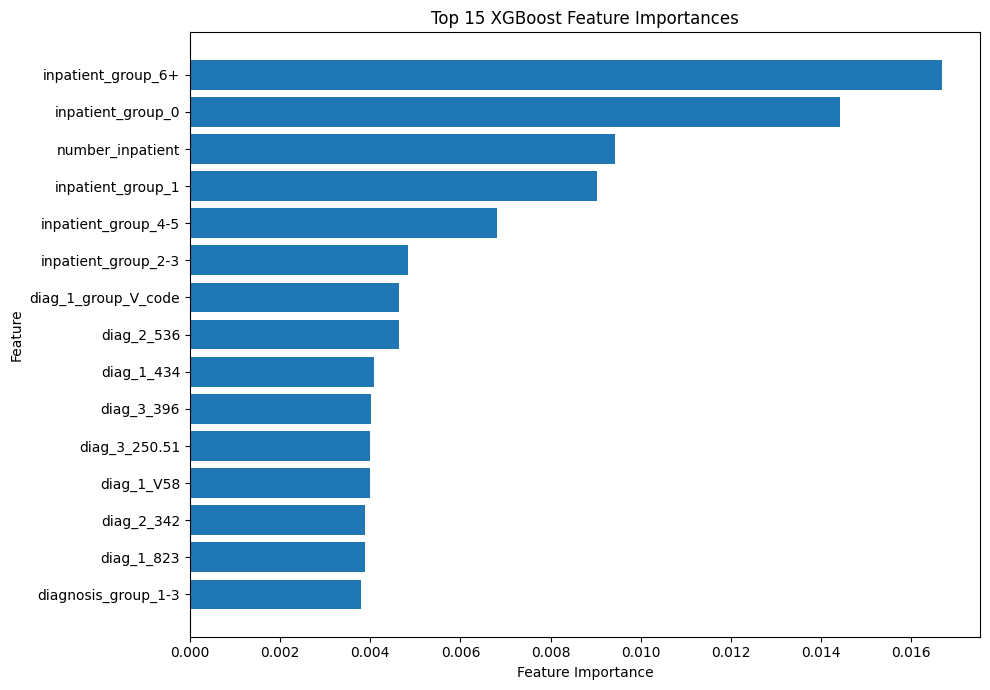

In [242]:
top_features = feature_importance_clean.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# 16. Conclusion

This project developed a machine learning pipeline to predict early hospital
readmission among patients with diabetes.

The workflow included patient-level train-test splitting, data cleaning,
exploratory data analysis, feature engineering, categorical encoding,
handling of class imbalance, and comparison of multiple machine learning
models.

Logistic Regression, Random Forest, and XGBoost were evaluated using ROC-AUC
and PR-AUC because the target variable was imbalanced. XGBoost achieved the
strongest validation performance and was selected for final evaluation.

A classification threshold of 0.116 was selected using the validation set
based on the F1-score. On the unseen test set, the final model achieved:

- ROC-AUC: 0.6582
- PR-AUC: 0.2028
- Positive-class precision: 0.17
- Positive-class recall: 0.54
- Positive-class F1-score: 0.26

The model therefore demonstrates moderate ability to distinguish between
patients with and without early readmission. The selected threshold allows
the model to identify approximately 54% of early-readmission cases, while
also producing a substantial number of false positives.

Feature importance analysis showed that previous inpatient utilization,
including `number_inpatient` and the engineered `inpatient_group` features,
was among the strongest predictive signals used by the model. Several
diagnosis-related features also contributed to the predictions.

The results demonstrate the complete process of developing, evaluating, and
interpreting a machine learning model for an imbalanced healthcare
classification problem.